# Piloto Cygnus · dato → acción → resultado

Monitoreo de asignación experimental persistente. **DEMO por defecto**, sin conexión ni escrituras. En LIVE lee vistas del DW local en una transacción de solo lectura y la cierra. Los datos sintéticos no son resultados de Cygnus.

El análisis principal conserva el grupo asignado (ITT), incluye a quienes no fueron contactados y espera maduración completa. Ninguna celda activa el experimento o declara ganador.

In [1]:
from pathlib import Path
import sys
import os
import json
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import binomtest

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/replica_cygnus').exists()), None)
assert ROOT is not None, 'Abrir desde el repositorio o notebooks/'
sys.path.insert(0, str(ROOT/'src'))
from replica_cygnus.lead_scoring.pilot import itt_comparison
MODE = os.environ.get('PILOT_NOTEBOOK_MODE', 'DEMO')  # cambiar a LIVE explícitamente
PILOT_ID = 'cygnus_contact_v1'
print('Modo:', MODE)

Modo: DEMO


In [ ]:
if MODE == 'DEMO':
    # Fixture sintética determinista: proporciones ilustrativas, no evidencia comercial.
    rows=[]
    for arm, positive in [('TREATMENT', 8), ('CONTROL', 5)]:
        for endpoint in ['separacion_14d', 'minuta_60d']:
            rows.append(dict(pilot_id=PILOT_ID, arm=arm, cohort_date='2026-01-01', codigo_proyecto='DEMO',
                outcome_name=endpoint, assigned=200, mature=200, observed=200, missing_mature=0,
                positives=positive if endpoint=='separacion_14d' else max(0,positive-3),
                with_actions=180 if arm=='TREATMENT' else 140, within_sla=150 if arm=='TREATMENT' else 90,
                cost_pen=600 if arm=='TREATMENT' else 400))
    summary=pd.DataFrame(rows)
    batches=pd.DataFrame([dict(source_rows=402,accepted_rows=400,existing_rows=1,rejected_rows=1,reconciled=True)])
    protocol={'treatment_fraction':.5,'target_per_arm':1000,'primary_outcome':'separacion_14d'}
    print('DEMO: muestra aún menor a la meta ilustrativa.')
elif MODE == 'LIVE':
    from replica_cygnus.connections import connect_postgres
    from replica_cygnus.settings import load_settings
    def frame(cur, query, params):
        cur.execute(query,params)
        return pd.DataFrame(cur.fetchall(), columns=[d.name for d in cur.description])
    with connect_postgres(load_settings()) as conn:
        with conn.cursor() as cur:
            cur.execute('SET TRANSACTION ISOLATION LEVEL REPEATABLE READ, READ ONLY')
            cur.execute("SET LOCAL statement_timeout='30s'")
            cur.execute('SELECT protocol FROM experiments.lead_pilots WHERE pilot_id=%s',(PILOT_ID,))
            row=cur.fetchone()
            assert row, 'Registrar piloto antes de monitorear LIVE'
            protocol=row[0]
            summary=frame(cur,'SELECT * FROM experiments.v_lead_pilot_summary WHERE pilot_id=%s',(PILOT_ID,))
            batches=frame(cur,'SELECT * FROM experiments.v_lead_pilot_reconciliation WHERE pilot_id=%s ORDER BY started_at DESC',(PILOT_ID,))
else:
    raise ValueError('MODE debe ser DEMO o LIVE')
display(summary)
display(batches.drop(columns=['reject_details'], errors='ignore'))

DEMO: muestra aún menor a la meta ilustrativa.


,pilot_id,arm,cohort_date,codigo_proyecto,outcome_name,assigned,mature,observed,missing_mature,positives,with_actions,within_sla,cost_pen
0,cygnus_contact_v1,TREATMENT,2026-01-01,DEMO,separacion_14d,200,200,200,0,8,180,150,600
1,cygnus_contact_v1,TREATMENT,2026-01-01,DEMO,minuta_60d,200,200,200,0,5,180,150,600
2,cygnus_contact_v1,CONTROL,2026-01-01,DEMO,separacion_14d,200,200,200,0,5,140,90,400
3,cygnus_contact_v1,CONTROL,2026-01-01,DEMO,minuta_60d,200,200,200,0,2,140,90,400


,source_rows,accepted_rows,existing_rows,rejected_rows,reconciled
0,402,400,1,1,True


## 1. Integridad antes de interpretar

Conciliar filas de entrada con aceptadas, existentes y rechazadas. Un rechazo no desaparece: revisar su motivo en la vista de conciliación. Cada endpoint repite los asignados y costos: filtrar uno para no duplicar totales.

In [3]:
PRIMARY=protocol['primary_outcome']
if not batches.empty:
    assert (batches.source_rows == batches.accepted_rows+batches.existing_rows+batches.rejected_rows).all(), 'Lotes no conciliados'
    print('Filas rechazadas acumuladas:', int(batches.rejected_rows.sum()))
if summary.empty:
    totals=pd.DataFrame()
    print('Sin asignaciones: no hay tasas que estimar.')
else:
    numeric=['assigned','mature','observed','missing_mature','positives','with_actions','within_sla','cost_pen']
    for col in numeric:
        summary[col]=pd.to_numeric(summary[col],errors='raise').fillna(0)
    totals=summary[summary.outcome_name==PRIMARY].groupby('arm')[numeric].sum().reindex(['TREATMENT','CONTROL'],fill_value=0)
    assert (totals.observed+totals.missing_mature==totals.mature).all()
    display(totals)
    if totals.assigned.sum():
        srm=binomtest(int(totals.loc['TREATMENT','assigned']),int(totals.assigned.sum()),p=protocol['treatment_fraction'])
        print('Diagnóstico de desbalance de asignación (p, no test de ventas):', round(srm.pvalue,6))

Filas rechazadas acumuladas: 1


,assigned,mature,observed,missing_mature,positives,with_actions,within_sla,cost_pen
arm,,,,,,,,
TREATMENT,200,200,200,0,8,180,150,600
CONTROL,200,200,200,0,5,140,90,400


Diagnóstico de desbalance de asignación (p, no test de ventas): 1.0


## 2. Adopción y captura de resultados

SLA = primer intento de llamada/WhatsApp desde asignación. No significa conversación efectiva. Revisar `result` en el registro operativo para distinguirlos. Los faltantes maduros son problemas de cobertura, no ceros.

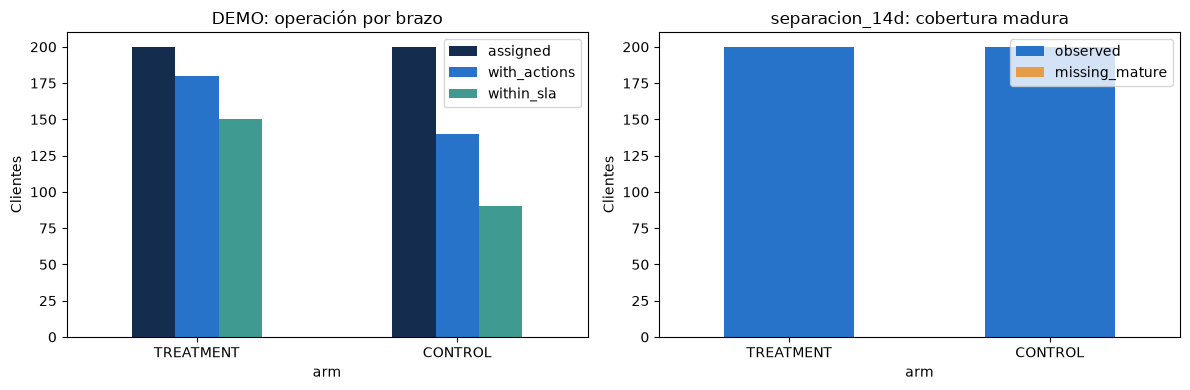

In [4]:
if not totals.empty and totals.assigned.sum():
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    totals[['assigned','with_actions','within_sla']].plot.bar(ax=axes[0],rot=0,color=['#142D4E','#2673C9','#3F9A91'])
    axes[0].set(title=f'{MODE}: operación por brazo',ylabel='Clientes')
    totals[['observed','missing_mature']].plot.bar(stacked=True,ax=axes[1],rot=0,color=['#2673C9','#E59B48'])
    axes[1].set(title=f'{PRIMARY}: cobertura madura',ylabel='Clientes')
    plt.tight_layout()
    plt.show()

## 3. ITT e incertidumbre

Se muestra diferencia tratamiento − control en puntos porcentuales e IC 95% Newcombe. Con faltantes se bloquea el estimador completo y se presentan límites extremos: no asumir que los faltantes se comportan igual en ambos grupos.

Las revisiones son descriptivas; la inferencia final requiere el plan preespecificado, muestra suficiente, maduración de toda la cohorte final y evaluación de multiplicidad. Minuta es secundaria si separación es primaria.

,status,difference_pp,ci95_low_pp,ci95_high_pp,relative_lift,endpoint,n_t,n_c,all_enrolled_mature,planned_sample_reached
0,DESCRIPTIVE_NOT_STOPPING_RULE,1.5,-2.267472,5.459497,0.6,separacion_14d,200,200,True,False
1,DESCRIPTIVE_NOT_STOPPING_RULE,1.5,-1.441756,4.798570,1.5,minuta_60d,200,200,True,False


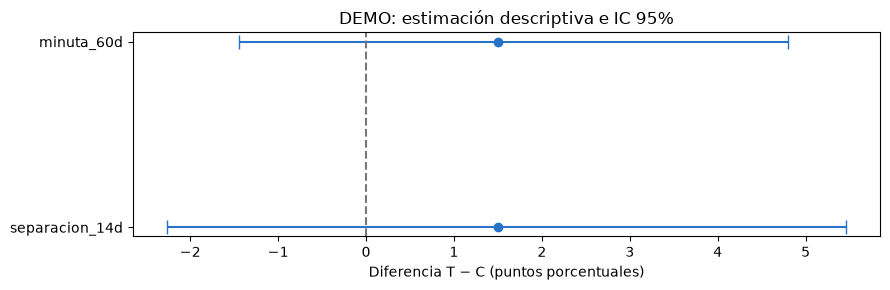

In [5]:
effects=[]
for endpoint in ['separacion_14d','minuta_60d']:
    if summary.empty: continue
    g=summary[summary.outcome_name==endpoint].groupby('arm')[['assigned','mature','positives','missing_mature']].sum().reindex(['TREATMENT','CONTROL'],fill_value=0)
    t,c=g.loc['TREATMENT'],g.loc['CONTROL']
    if min(t.mature,c.mature)==0:
        print(endpoint, ': sin denominador maduro en ambos brazos'); continue
    if g.missing_mature.sum()>0:
        low=t.positives/t.mature-(c.positives+c.missing_mature)/c.mature
        high=(t.positives+t.missing_mature)/t.mature-c.positives/c.mature
        print(endpoint, ': BLOQUEADO por faltantes. Límites extremos pp:', 100*low,100*high)
        continue
    result=itt_comparison(int(t.positives),int(t.mature),int(c.positives),int(c.mature))
    result.update(endpoint=endpoint, n_t=int(t.mature), n_c=int(c.mature),
        all_enrolled_mature=bool((g.assigned==g.mature).all()),
        planned_sample_reached=bool(min(t.assigned,c.assigned)>=protocol['target_per_arm']))
    effects.append(result)
effects=pd.DataFrame(effects)
display(effects)
if not effects.empty:
    fig,ax=plt.subplots(figsize=(9,3))
    for i,r in effects.iterrows():
        ax.errorbar(r.difference_pp,i,xerr=[[r.difference_pp-r.ci95_low_pp],[r.ci95_high_pp-r.difference_pp]],fmt='o',color='#2673C9',capsize=5)
    ax.axvline(0,color='#777777',linestyle='--')
    ax.set(yticks=range(len(effects)),yticklabels=effects.endpoint,xlabel='Diferencia T − C (puntos porcentuales)',title=f'{MODE}: estimación descriptiva e IC 95%')
    plt.tight_layout(); plt.show()

## 4. Planificar muestra y plazo antes de activar

Completar tasa base observada en población elegible y MDE comercial. Aproximación normal para dos proporciones; no reemplaza simulación con eventos raros, desbalance, interferencias o múltiples pruebas. El SLA de respuesta y los 14/60 días de maduración son relojes distintos.

In [6]:
BASE_RATE=None  # proporción real en población comparable
MDE_PP=None     # mejora absoluta mínima, en puntos porcentuales
ELIGIBLE_PER_DAY=None  # nuevos clientes únicos elegibles, no stock de leads
if all(v is not None for v in [BASE_RATE,MDE_PP,ELIGIBLE_PER_DAY]):
    from statsmodels.stats.power import NormalIndPower
    from statsmodels.stats.proportion import proportion_effectsize
    assert 0<BASE_RATE<BASE_RATE+MDE_PP/100<1 and ELIGIBLE_PER_DAY>0
    fraction=protocol['treatment_fraction']
    effect=abs(proportion_effectsize(BASE_RATE+MDE_PP/100,BASE_RATE))
    n_t=math.ceil(NormalIndPower().solve_power(effect_size=effect,alpha=.05,power=.8,ratio=(1-fraction)/fraction,alternative='two-sided'))
    n_c=math.ceil(n_t*(1-fraction)/fraction)
    print({'treatment':n_t,'control':n_c,'recruitment_days_approx':math.ceil((n_t+n_c)/ELIGIBLE_PER_DAY),
           'followup_after_last_enrollment_days':{'separacion_14d':14,'minuta_60d':60}[PRIMARY]})
else:
    print('Plan de potencia pendiente: no fijar duración a partir de 2017 leads históricos.')

Plan de potencia pendiente: no fijar duración a partir de 2017 leads históricos.


## 5. Valor económico y decisión

Margen incremental por cliente = diferencia de conversión a minuta × margen de contribución por minuta − costo incremental por cliente. Definir costos homogéneos y la misma ventana de seguimiento; las vistas actuales suman acciones registradas hasta la consulta. No usar ese costo para comparar horizontes distintos sin recortarlo primero.

Decisión final humana: ¿muestra y cobertura suficientes?, ¿IC compatible con mejora útil?, ¿adherencia y efectos adversos aceptables?, ¿margen incremental positivo? No escalar solo por AUC o por un valor p.

Checklist de comité: protocolo aprobado; identidad estable; modelo congelado; conciliación; balance de asignación y características iniciales; contaminación; ITT con cobertura completa; intervalos; economía; decisión y responsable. Resultados por asesor/proyecto son exploratorios y no rankings causales.

Fuentes: [Newcombe en statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.confint_proportions_2indep.html), [potencia de dos muestras](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.NormalIndPower.html).